## 1. Importamos librerías y preparamos los datos
En esta celda vamos a importar las librerías necesarias, definir los datos de entrada del problema, fijar una semilla para que el experimento sea reproducible e inicializar aleatoriamente los pesos, el sesgo, la tasa de aprendizaje y el número máximo de épocas del perceptrón.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de entrada
X1 = np.array([1, 0, 3, 5, 8, 3, 5], dtype=float)
X2 = np.array([1, 2, 3, 7, 9, 8, 6], dtype=float)
D  = np.array([0, 0, 1, 1, 1, 1, 1], dtype=int)

# Para reproducibilidad
np.random.seed(42)

# Inicialización aleatoria de pesos y sesgo
w1 = np.random.rand()
w2 = np.random.rand()
b = np.random.rand()

# Tasa de aprendizaje
alfa = 0.1

# Número máximo de épocas
epocas = 10

print(f"Pesos iniciales: w1={w1:.4f}, w2={w2:.4f}, b={b:.4f}")

Pesos iniciales: w1=0.3745, w2=0.9507, b=0.7320


### Interpretación
La salida muestra los valores iniciales de `w1`, `w2` y `b`. Como se han generado de forma aleatoria pero con semilla fija, siempre obtendremos los mismos valores iniciales y podremos seguir la evolución del entrenamiento de manera consistente.

## 2. Entrenamos el perceptrón
Ahora vamos a entrenar el perceptrón durante varias épocas. En cada iteración calcularemos la salida lineal `Z`, aplicaremos la función escalón para obtener la predicción `Y`, mediremos el error respecto a la salida deseada `D` y actualizaremos pesos y sesgo patrón a patrón hasta que no haya errores o se alcance el máximo de épocas.

In [2]:
for epoca in range(epocas):
    print(f"\nÉpoca {epoca+1}")

    # Cálculo lineal del perceptrón
    Z = w1 * X1 + w2 * X2 - b

    # Función escalón
    Y = np.where(Z > 0, 1, 0)

    # Error
    E = D - Y

    print("Z =", np.round(Z, 3))
    print("Y =", Y)
    print("E =", E)

    # Ajuste de pesos y sesgo patrón a patrón
    for i in range(len(X1)):
        error = E[i]
        b_inc  = -alfa * error
        w1_inc = alfa * error * X1[i]
        w2_inc = alfa * error * X2[i]

        b  = b + b_inc
        w1 = w1 + w1_inc
        w2 = w2 + w2_inc

    print(f"Pesos actualizados: w1={w1:.4f}, w2={w2:.4f}, b={b:.4f}")

    # Si ya no hay error, paramos
    if np.sum(np.abs(E)) == 0:
        print("El perceptrón ha convergido.")
        break


Época 1
Z = [ 0.593  1.169  3.244  7.796 10.821  7.997  6.845]
Y = [1 1 1 1 1 1 1]
E = [-1 -1  0  0  0  0  0]
Pesos actualizados: w1=0.2745, w2=0.6507, b=0.9320

Época 2
Z = [-7.000e-03  3.690e-01  1.844e+00  4.996e+00  7.121e+00  5.097e+00
  4.345e+00]
Y = [0 1 1 1 1 1 1]
E = [ 0 -1  0  0  0  0  0]
Pesos actualizados: w1=0.2745, w2=0.4507, b=1.0320

Época 3
Z = [-0.307 -0.131  1.144  3.496  5.221  3.397  3.045]
Y = [0 0 1 1 1 1 1]
E = [0 0 0 0 0 0 0]
Pesos actualizados: w1=0.2745, w2=0.4507, b=1.0320
El perceptrón ha convergido.


### Resultados del entrenamiento
En la primera época el modelo clasifica todos los patrones como clase 1, por eso aparecen errores en los dos primeros ejemplos. Tras ajustar los pesos y el sesgo, en la segunda época ya solo falla un patrón y en la tercera el error es nulo. Esto indica que el perceptrón ha convergido y ha encontrado una frontera lineal que separa correctamente las dos clases.

## 3. Representamos la frontera de decisión
En esta celda vamos a representar los patrones de las dos clases en el plano `X1-X2` y dibujar la recta de decisión aprendida por el perceptrón a partir de los pesos finales.

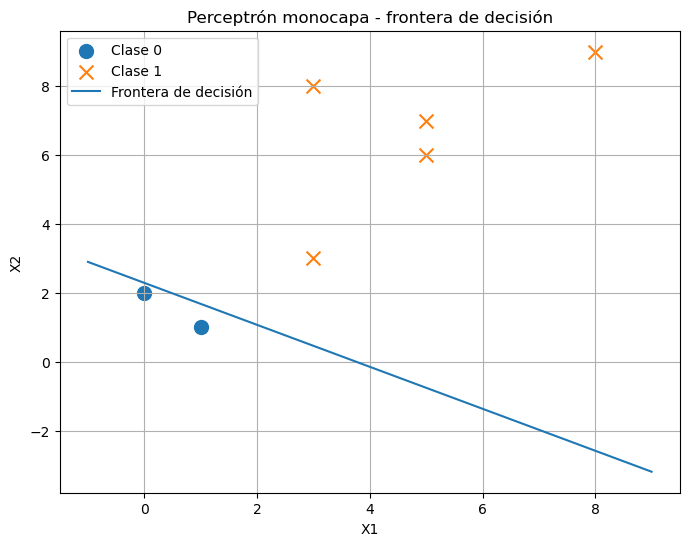

In [3]:
# Separamos puntos por clase
clase_0 = D == 0
clase_1 = D == 1

plt.figure(figsize=(8,6))

plt.scatter(X1[clase_0], X2[clase_0], marker='o', s=100, label='Clase 0')
plt.scatter(X1[clase_1], X2[clase_1], marker='x', s=100, label='Clase 1')

# Frontera de decisión: w1*x1 + w2*x2 - b = 0
# x2 = (-w1*x1 + b) / w2
x_vals = np.linspace(min(X1)-1, max(X1)+1, 100)

if w2 != 0:
    y_vals = (-w1 * x_vals + b) / w2
    plt.plot(x_vals, y_vals, label='Frontera de decisión')
else:
    print("No se puede dibujar la recta porque w2 = 0")

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Perceptrón monocapa - frontera de decisión")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación del gráfico
La gráfica permite comprobar visualmente que la recta obtenida separa los puntos de la clase 0 de los de la clase 1. Los dos patrones negativos quedan a un lado de la frontera y los positivos al otro, lo que confirma de forma visual la convergencia observada durante el entrenamiento.

## 4. Comprobamos la salida final del modelo
Ahora vamos a calcular la salida final del perceptrón con los pesos entrenados y la compararemos directamente con la salida deseada para verificar si todos los patrones quedan bien clasificados.

In [4]:
Z_final = w1 * X1 + w2 * X2 - b
Y_final = np.where(Z_final > 0, 1, 0)

print("Salida final del modelo:", Y_final)
print("Salida deseada        :", D)

if np.array_equal(Y_final, D):
    print("Clasificación correcta de todos los patrones.")
else:
    print("Todavía hay errores de clasificación.")

Salida final del modelo: [0 0 1 1 1 1 1]
Salida deseada        : [0 0 1 1 1 1 1]
Clasificación correcta de todos los patrones.


La predicción final coincide exactamente con el vector objetivo `D`: `[0, 0, 1, 1, 1, 1, 1]`. Por tanto, el perceptrón clasifica correctamente todos los ejemplos del conjunto de entrenamiento.

## 5. Construimos la tabla resumen de resultados
En esta última celda vamos a construir una tabla con los datos de entrada, la activación final `Z`, la clase predicha y una columna lógica que indique si cada patrón ha sido clasificado correctamente.

In [5]:
import pandas as pd

df_resultado = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "D_real": D,
    "Z_final": np.round(Z_final, 4),
    "Y_pred": Y_final,
    "Correcto": D == Y_final
})

df_resultado

,X1,X2,D_real,Z_final,Y_pred,Correcto
0,1.0,1.0,0,-0.3067,0,True
1,0.0,2.0,0,-0.1306,0,True
2,3.0,3.0,1,1.1438,1,True
3,5.0,7.0,1,3.4957,1,True
4,8.0,9.0,1,5.2208,1,True
5,3.0,8.0,1,3.3973,1,True
6,5.0,6.0,1,3.0450,1,True


### Conclusión de la tabla
La tabla confirma que todos los patrones aparecen con `Correcto = True`. Además, se ve que `Z_final` es negativa en los ejemplos de clase 0 y positiva en los de clase 1, que es justo el comportamiento esperado en un perceptrón con función escalón.